# Réseaux Neuronnes

## MLP avec torch

[A] Epoch 1 | loss=0.3528
[A] Epoch 2 | loss=0.3424
[A] Epoch 3 | loss=0.3407
[A] Epoch 4 | loss=0.3375
[A] Epoch 5 | loss=0.3360
[A] Epoch 6 | loss=0.3347
[A] Epoch 7 | loss=0.3344
[A] Epoch 8 | loss=0.3336
[A] Epoch 9 | loss=0.3327
[A] Epoch 10 | loss=0.3317
class weights: tensor([0.5636, 4.4300])
[B] Epoch 1 | loss=0.6814
[B] Epoch 2 | loss=0.6601
[B] Epoch 3 | loss=0.6554
[B] Epoch 4 | loss=0.6512
[B] Epoch 5 | loss=0.6486
[B] Epoch 6 | loss=0.6472
[B] Epoch 7 | loss=0.6457
[B] Epoch 8 | loss=0.6447
[B] Epoch 9 | loss=0.6416
[B] Epoch 10 | loss=0.6417

===== MLP_Weighted vs MLP_Normal — TEST =====

             MLP_Weighted  MLP_Normal       Δ
ROC_AUC            0.6610      0.6572  0.0038
PR_AUC             0.2112      0.2106  0.0006
Recall_1           0.6882      0.0149  0.6733
Precision_1        0.1609      0.6471 -0.4862
F1_1               0.2608      0.0292  0.2316


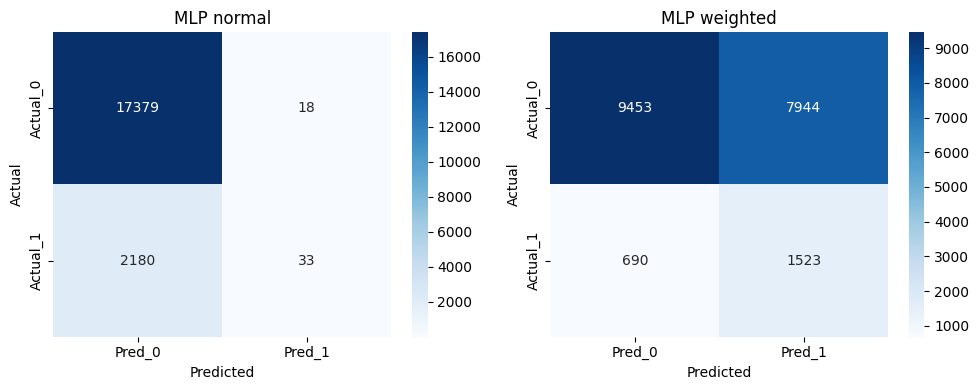

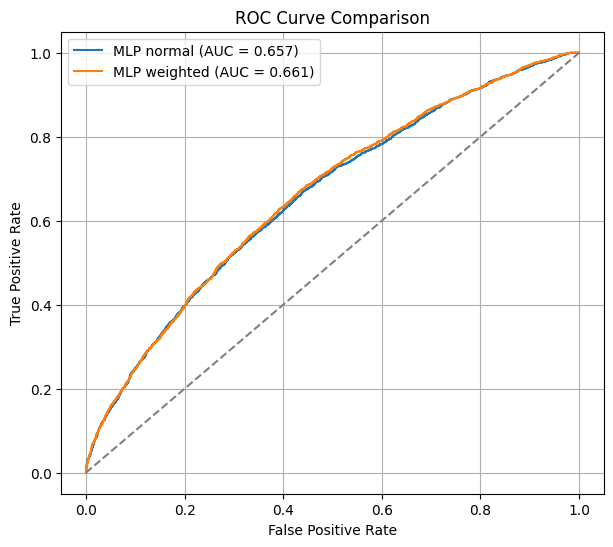

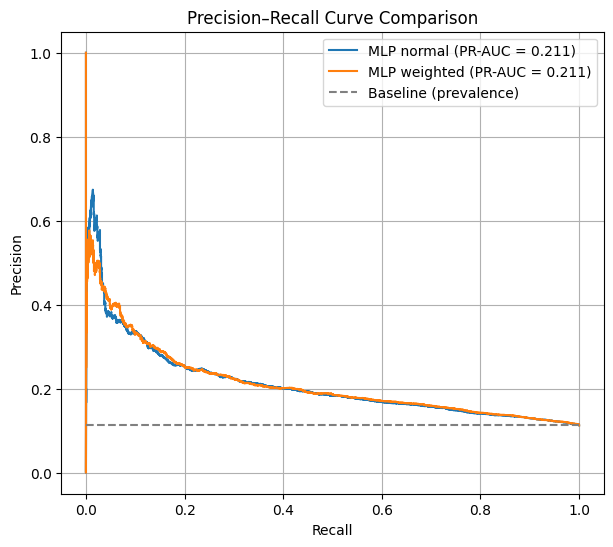

In [20]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.functional import softmax

from metrics_utils import (
    metrics_comparison,
    plot_roc_comparison,
    plot_pr_comparison,
    plot_confusion_matrices
)

# 1) Données


X_train = pd.read_csv("données/X_train.csv")
X_test  = pd.read_csv("données/X_test.csv")

Y_train = pd.read_csv("données/Y_train.csv")
Y_test  = pd.read_csv("données/Y_est.csv")  

num_cols = X_train.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_maps = {}

for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col]  = X_test[col].astype("category")

    X_train[col], mapping = X_train[col].factorize()
    X_test[col] = X_test[col].map({cat: i for i, cat in enumerate(mapping)})

    X_train[col], mapping = X_train[col].factorize()
    cat_maps[col] = mapping

# tensors
X_num_t = torch.tensor(X_train[num_cols].values, dtype=torch.float32)
X_cat_t = torch.tensor(X_train[cat_cols].values, dtype=torch.long)

X_num_test_t = torch.tensor(X_test[num_cols].values, dtype=torch.float32)
X_cat_test_t = torch.tensor(X_test[cat_cols].values, dtype=torch.long)

y_t = torch.tensor(Y_train.values, dtype=torch.long).view(-1)
y_test_t = torch.tensor(Y_test.values, dtype=torch.long).view(-1)


# 2) Embeddings


embedding_sizes = []
for col in cat_cols:
    n_cat = X_train[col].nunique() + 1
    emb_dim = min(50, (n_cat // 2) + 1)
    embedding_sizes.append((n_cat, emb_dim))



# 3) Model


class TabularModel(nn.Module):
    def __init__(self, embedding_sizes, n_numeric, n_classes):
        super().__init__()

        self.emb_layers = nn.ModuleList([
            nn.Embedding(n_cat, emb)
            for n_cat, emb in embedding_sizes
        ])

        emb_total = sum([emb for _, emb in embedding_sizes])

        self.fc = nn.Sequential(
            nn.Linear(emb_total + n_numeric, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_classes)
        )

    def forward(self, x_cat, x_num):
        embs = [emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.emb_layers)]
        x = torch.cat(embs + [x_num], dim=1)
        return self.fc(x)



# 4) Loaders


train_ds = TensorDataset(X_cat_t, X_num_t, y_t)
test_ds  = TensorDataset(X_cat_test_t, X_num_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)


def train_epoch(model, optimizer, criterion):
    model.train()
    total = 0

    for xc, xn, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xc, xn)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total += loss.item()

    return total / len(train_loader)



# 6) MODEL sans calss weigths


model_A = TabularModel(embedding_sizes, len(num_cols), 2)
criterion_A = nn.CrossEntropyLoss()
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=1e-3)

for e in range(10):
    print(f"[A] Epoch {e+1} | loss={train_epoch(model_A, optimizer_A, criterion_A):.4f}")


# 7) class waigths


n_pos = (y_t == 1).sum().item()
n_neg = (y_t == 0).sum().item()
total = n_pos + n_neg

class_weights = torch.tensor([
    total / (2 * n_neg),
    total / (2 * n_pos)
], dtype=torch.float32)

print("class weights:", class_weights)



# 8) Model avec weigths


model_B = TabularModel(embedding_sizes, len(num_cols), 2)
criterion_B = nn.CrossEntropyLoss(weight=class_weights)
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=1e-3)

for e in range(10):
    print(f"[B] Epoch {e+1} | loss={train_epoch(model_B, optimizer_B, criterion_B):.4f}")


# 9) Prediction

def predict(model):
    model.eval()
    all_pred, all_proba = [], []

    with torch.no_grad():
        for xc, xn, _ in test_loader:
            logits = model(xc, xn)
            p = softmax(logits, dim=1)[:, 1]

            all_proba.extend(p.tolist())
            all_pred.extend((p >= 0.5).long().tolist())

    return np.array(all_pred), np.array(all_proba)


y_pred_A, y_proba_A = predict(model_A)
y_pred_B, y_proba_B = predict(model_B)



# 10) Metrics


metrics_comparison(
    y_true=Y_test,
    y_pred=y_pred_B,
    y_proba=y_proba_B,
    y_pred_bench=y_pred_A,
    y_proba_bench=y_proba_A,
    model_name="MLP_Weighted",
    benchmark_name="MLP_Normal"
)

plot_confusion_matrices(
    y_true=Y_test,
    y_pred_1=y_pred_A,
    y_pred_2=y_pred_B,
    model_names=("MLP normal", "MLP weighted")
)

plot_roc_comparison(
    y_true=Y_test,
    y_proba_dict={
        "MLP normal": y_proba_A,
        "MLP weighted": y_proba_B
    }
)

plot_pr_comparison(
    y_true=Y_test,
    y_proba_dict={
        "MLP normal": y_proba_A,
        "MLP weighted": y_proba_B
    }
)
